# Checkpoint 1 – Procesarea și Analiza Datelor
## Student Mental Health & Burnout Dataset (1M înregistrări)

**Obiective:**
- Curățarea datelor: identificarea valorilor lipsă, tratarea valorilor anormale (outlieri)
- Filtrarea, sortarea, gruparea și agregarea datelor
- Vizualizări de bază pentru a înțelege structura și relațiile dintre date

### Setul de date
Setul de date conține **1.000.000 de înregistrări** despre sănătatea mintală și burnout-ul studenților, cu 20 de coloane:

| Coloana | Tip | Descriere |
|---------|-----|-----------|
| `age` | numeric | Vârsta studentului (17–29 ani) |
| `gender` | categoric | Genul (Male/Female) |
| `academic_year` | numeric | Anul universitar (1–4) |
| `study_hours_per_day` | numeric | Ore de studiu pe zi |
| `exam_pressure` | numeric | Presiunea examenelor (1–10) |
| `academic_performance` | numeric | Performanța academică (0–100) |
| `stress_level` | numeric | Nivelul de stres (0–10) |
| `anxiety_score` | numeric | Scorul de anxietate (0–10) |
| `depression_score` | numeric | Scorul de depresie (0–10) |
| `sleep_hours` | numeric | Ore de somn pe noapte |
| `physical_activity` | numeric | Activitate fizică (0–7 ore/săpt) |
| `social_support` | numeric | Suport social (0–10) |
| `screen_time` | numeric | Timp pe ecran (ore/zi) |
| `internet_usage` | numeric | Utilizare internet (ore/zi) |
| `financial_stress` | numeric | Stres financiar (0–10) |
| `family_expectation` | numeric | Așteptări familiale (0–10) |
| `burnout_score` | numeric | Scorul de burnout (0–10) |
| `mental_health_index` | numeric | Indicele de sănătate mintală (0–10) |
| `risk_level` | categoric | Nivel de risc (Low/Medium/High) |
| `dropout_risk` | numeric | Riscul de abandon (0–10) |

### Biblioteci folosite
- `pandas` – manipularea datelor
- `numpy` – calcule numerice
- `matplotlib` – grafice de bază
- `seaborn` – grafice statistice avansate
- `scipy` – statistici (Z-score)

---
## 1. Setup – Importuri și Configurare

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurare globala pentru grafice
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

print('Biblioteci importate cu succes!')

Biblioteci importate cu succes!


---
## 2. Încărcarea și Prima Explorare a Datelor (EDA)

In [2]:
# Incarcarea setului de date
CSV_PATH = 'student_mental_health_burnout_1M (1).csv'

df = pd.read_csv(CSV_PATH)
print(f'Dataset incarcat cu succes!')
print(f'  Dimensiuni: {df.shape[0]:,} randuri x {df.shape[1]} coloane')
print(f'  Memorie: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

Dataset incarcat cu succes!
  Dimensiuni: 1,000,000 randuri x 20 coloane
  Memorie: 239.1 MB


In [3]:
# Primele 5 randuri
df.head()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


In [4]:
# Informatii despre tipurile de date si valorile non-null
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  str    
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 14  financial_stress      1000000 non-null  float6

In [5]:
# Statistici descriptive pentru coloanele numerice
df.describe().round(3)

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
count,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000
mean,22.996,2.501,5.002,5.999,70.999,4.246,2.986,1.275,6.502,3.011,5.000,5.019,5.038,5.003,5.983,1.784,7.023,1.325
std,3.743,1.118,1.989,1.548,5.660,1.679,1.510,1.221,1.473,1.464,1.977,1.961,2.158,1.976,1.961,1.664,1.311,1.343
min,17.000,1.000,0.000,1.000,42.366,0.000,0.000,0.000,3.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.310,0.000
25%,20.000,2.000,3.651,4.945,67.181,3.103,1.924,0.005,5.491,1.991,3.650,3.651,3.491,3.657,4.647,0.125,6.142,0.000
50%,23.000,3.000,4.998,5.999,71.000,4.244,2.970,1.048,6.502,3.001,4.999,5.004,5.002,5.001,6.000,1.497,7.074,1.010
75%,26.000,4.000,6.346,7.052,74.821,5.385,4.015,2.086,7.515,4.011,6.350,6.351,6.507,6.355,7.352,2.889,7.962,2.174
max,29.000,4.000,14.000,10.000,97.246,10.000,10.000,8.531,10.000,7.000,10.000,12.000,14.000,10.000,10.000,10.000,10.000,9.326


In [6]:
# Coloane categorice – valori unice
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Coloane categorice: {cat_cols}\n')

for col in cat_cols:
    print(f'  {col}: {df[col].unique()} (nunique={df[col].nunique()})')

Coloane categorice: ['gender', 'risk_level']

  gender: <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str (nunique=3)
  risk_level: <StringArray>
['Low', 'High', 'Medium']
Length: 3, dtype: str (nunique=3)


---
## 3. Curățarea Datelor

### 3.1 Identificarea Valorilor Lipsă

In [7]:
# Numar de valori lipsa per coloana
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valori lipsa': missing,
    'Procent (%)': missing_pct
})
print('=== Valori Lipsa per Coloana ===')
print(missing_df)

if missing.sum() == 0:
    print('\n[OK] Setul de date nu contine valori lipsa!')
else:
    print(f'\n[!] Total celule lipsa: {missing.sum():,}')

=== Valori Lipsa per Coloana ===
                      Valori lipsa  Procent (%)
age                              0          0.0
gender                           0          0.0
academic_year                    0          0.0
study_hours_per_day              0          0.0
exam_pressure                    0          0.0
academic_performance             0          0.0
stress_level                     0          0.0
anxiety_score                    0          0.0
depression_score                 0          0.0
sleep_hours                      0          0.0
physical_activity                0          0.0
social_support                   0          0.0
screen_time                      0          0.0
internet_usage                   0          0.0
financial_stress                 0          0.0
family_expectation               0          0.0
burnout_score                    0          0.0
mental_health_index              0          0.0
risk_level                       0          0.0
dropout

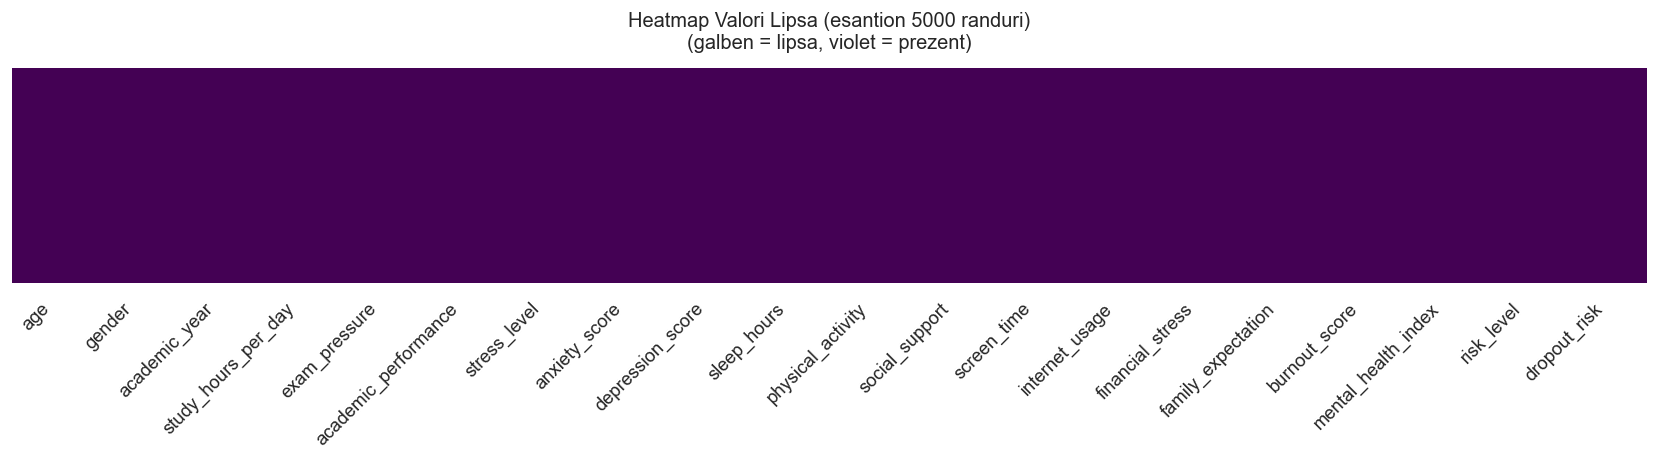

In [8]:
# Vizualizare heatmap valori lipsa (util pentru datasets cu NaN-uri)
# Luam un esantion de 5000 randuri pentru vizualizare
sample_for_missing = df.sample(5000, random_state=42)

plt.figure(figsize=(14, 4))
sns.heatmap(
    sample_for_missing.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis'
)
plt.title('Heatmap Valori Lipsa (esantion 5000 randuri)\n(galben = lipsa, violet = prezent)', pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.2 Verificarea Valorilor Invalide

Chiar dacă nu există valori lipsă, trebuie să verificăm dacă valorile se încadrează în domeniile logice (ex: ore de somn negative, burnout > 10 etc.).

In [9]:
# Verificarea domeniilor logice
domenii_logice = {
    'age':                  (17, 29),
    'academic_year':        (1, 4),
    'study_hours_per_day':  (0, 24),
    'exam_pressure':        (0, 10),
    'academic_performance': (0, 100),
    'stress_level':         (0, 10),
    'anxiety_score':        (0, 10),
    'depression_score':     (0, 10),
    'sleep_hours':          (0, 24),
    'physical_activity':    (0, 7),
    'social_support':       (0, 10),
    'screen_time':          (0, 24),
    'internet_usage':       (0, 24),
    'financial_stress':     (0, 10),
    'family_expectation':   (0, 10),
    'burnout_score':        (0, 10),
    'mental_health_index':  (0, 10),
    'dropout_risk':         (0, 10),
}

print('=== Verificare Domenii Logice ===')
found_invalid = False
for col, (vmin, vmax) in domenii_logice.items():
    n_invalid = ((df[col] < vmin) | (df[col] > vmax)).sum()
    if n_invalid > 0:
        print(f'  [!] {col}: {n_invalid:,} valori in afara [{vmin}, {vmax}]')
        found_invalid = True
    else:
        print(f'  [OK] {col}: toate valorile in [{vmin}, {vmax}]')

if not found_invalid:
    print('\n[OK] Toate valorile sunt in domeniile logice!')

=== Verificare Domenii Logice ===
  [OK] age: toate valorile in [17, 29]
  [OK] academic_year: toate valorile in [1, 4]
  [OK] study_hours_per_day: toate valorile in [0, 24]
  [OK] exam_pressure: toate valorile in [0, 10]
  [OK] academic_performance: toate valorile in [0, 100]
  [OK] stress_level: toate valorile in [0, 10]
  [OK] anxiety_score: toate valorile in [0, 10]
  [OK] depression_score: toate valorile in [0, 10]
  [OK] sleep_hours: toate valorile in [0, 24]
  [OK] physical_activity: toate valorile in [0, 7]
  [OK] social_support: toate valorile in [0, 10]
  [OK] screen_time: toate valorile in [0, 24]
  [OK] internet_usage: toate valorile in [0, 24]
  [OK] financial_stress: toate valorile in [0, 10]
  [OK] family_expectation: toate valorile in [0, 10]
  [OK] burnout_score: toate valorile in [0, 10]
  [OK] mental_health_index: toate valorile in [0, 10]
  [OK] dropout_risk: toate valorile in [0, 10]

[OK] Toate valorile sunt in domeniile logice!


In [10]:
# Verificare coloane categorice – valori asteptate
print('Valori unice gender:', df['gender'].unique())
print('Valori unice risk_level:', df['risk_level'].unique())

# Verificare gender encoding consistent
expected_genders = {'Male', 'Female'}
actual_genders = set(df['gender'].unique())
if actual_genders == expected_genders:
    print('\n[OK] Coloana gender contine doar valori valide: Male / Female')
else:
    print(f'\n[!] Valori neasteptate in gender: {actual_genders - expected_genders}')

# Verificare risk_level
expected_risks = {'Low', 'Medium', 'High'}
actual_risks = set(df['risk_level'].unique())
if actual_risks == expected_risks:
    print('[OK] Coloana risk_level contine doar valori valide: Low / Medium / High')
else:
    print(f'[!] Valori neasteptate in risk_level: {actual_risks - expected_risks}')

Valori unice gender: <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
Valori unice risk_level: <StringArray>
['Low', 'High', 'Medium']
Length: 3, dtype: str

[!] Valori neasteptate in gender: {'Other'}
[OK] Coloana risk_level contine doar valori valide: Low / Medium / High


### 3.3 Detectarea Valorilor Anormale (Outlieri)

Vom aplica două metode clasice de detecție a outlierilor:

| Metodă | Cum funcționează | Când o folosim |
|--------|------------------|----------------|
| **IQR** | Bazată pe cuartile (Q1, Q3) | Date asimetrice, robustă |
| **Z-score** | Bazată pe medie și deviație standard | Date ~normal distribuite |

Vom analiza coloanele cheie: `burnout_score`, `stress_level`, `study_hours_per_day`.

In [11]:
def detectie_outlieri_iqr(df, coloana):
    """
    Detecteaza outlierii folosind metoda IQR.
    Returneaza limitele si un boolean mask cu outlierii.
    """
    Q1 = df[coloana].quantile(0.25)
    Q3 = df[coloana].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask_outlieri = (df[coloana] < lower) | (df[coloana] > upper)
    return Q1, Q3, IQR, lower, upper, mask_outlieri


def detectie_outlieri_zscore(df, coloana, prag=3.0):
    """
    Detecteaza outlierii folosind metoda Z-score.
    Returneaza z-score-urile si un boolean mask cu outlierii.
    """
    z_scores = np.abs(stats.zscore(df[coloana]))
    mask_outlieri = z_scores > prag
    return z_scores, mask_outlieri


print('Functii de detectie outlieri definite.')

Functii de detectie outlieri definite.


In [12]:
# --- Aplicare IQR pe coloana burnout_score ---
coloana_analiza = 'burnout_score'

Q1, Q3, IQR, lower, upper, mask_iqr = detectie_outlieri_iqr(df, coloana_analiza)

print(f'=== Analiza Outlieri IQR – {coloana_analiza} ===')
print(f'  Q1 (percentila 25):  {Q1:.3f}')
print(f'  Q3 (percentila 75):  {Q3:.3f}')
print(f'  IQR (Q3 - Q1):       {IQR:.3f}')
print(f'  Limita inferioara:   {lower:.3f}')
print(f'  Limita superioara:   {upper:.3f}')
print(f'\n  Outlieri gasiti:     {mask_iqr.sum():,} din {len(df):,} ({100*mask_iqr.mean():.2f}%)')

=== Analiza Outlieri IQR – burnout_score ===
  Q1 (percentila 25):  0.125
  Q3 (percentila 75):  2.889
  IQR (Q3 - Q1):       2.765
  Limita inferioara:   -4.022
  Limita superioara:   7.036

  Outlieri gasiti:     3,735 din 1,000,000 (0.37%)


In [13]:
# --- Aplicare Z-score pe coloana burnout_score ---
z_scores, mask_zscore = detectie_outlieri_zscore(df, coloana_analiza, prag=3.0)

print(f'=== Analiza Outlieri Z-score – {coloana_analiza} ===')
print(f'  Media:              {df[coloana_analiza].mean():.3f}')
print(f'  Deviatia standard:  {df[coloana_analiza].std():.3f}')
print(f'  Prag Z-score:       |z| > 3.0')
print(f'\n  Outlieri gasiti:    {mask_zscore.sum():,} din {len(df):,} ({100*mask_zscore.mean():.2f}%)')

=== Analiza Outlieri Z-score – burnout_score ===
  Media:              1.784
  Deviatia standard:  1.664
  Prag Z-score:       |z| > 3.0

  Outlieri gasiti:    5,457 din 1,000,000 (0.55%)


In [14]:
# Comparatie IQR vs Z-score
idx_iqr = set(df[mask_iqr].index)
idx_zscore = set(df[mask_zscore].index)

comuni = idx_iqr.intersection(idx_zscore)
doar_iqr = idx_iqr - idx_zscore
doar_zscore = idx_zscore - idx_iqr

skewness = df[coloana_analiza].skew()

print(f'=== Comparatie IQR vs Z-Score – {coloana_analiza} ===')
print(f'  Outlieri IQR:        {len(idx_iqr):,}')
print(f'  Outlieri Z-score:    {len(idx_zscore):,}')
print(f'  Comuni (ambele):     {len(comuni):,}')
print(f'  Doar IQR:            {len(doar_iqr):,}')
print(f'  Doar Z-score:        {len(doar_zscore):,}')
print(f'\n  Skewness (asimetrie): {skewness:.3f}')
if abs(skewness) > 0.5:
    print('  -> Distributie ASIMETRICA – metoda IQR este mai potrivita!')
else:
    print('  -> Distributie aproximativ simetrica – ambele metode sunt potrivite.')

=== Comparatie IQR vs Z-Score – burnout_score ===
  Outlieri IQR:        3,735
  Outlieri Z-score:    5,457
  Comuni (ambele):     3,735
  Doar IQR:            0
  Doar Z-score:        1,722

  Skewness (asimetrie): 0.806
  -> Distributie ASIMETRICA – metoda IQR este mai potrivita!


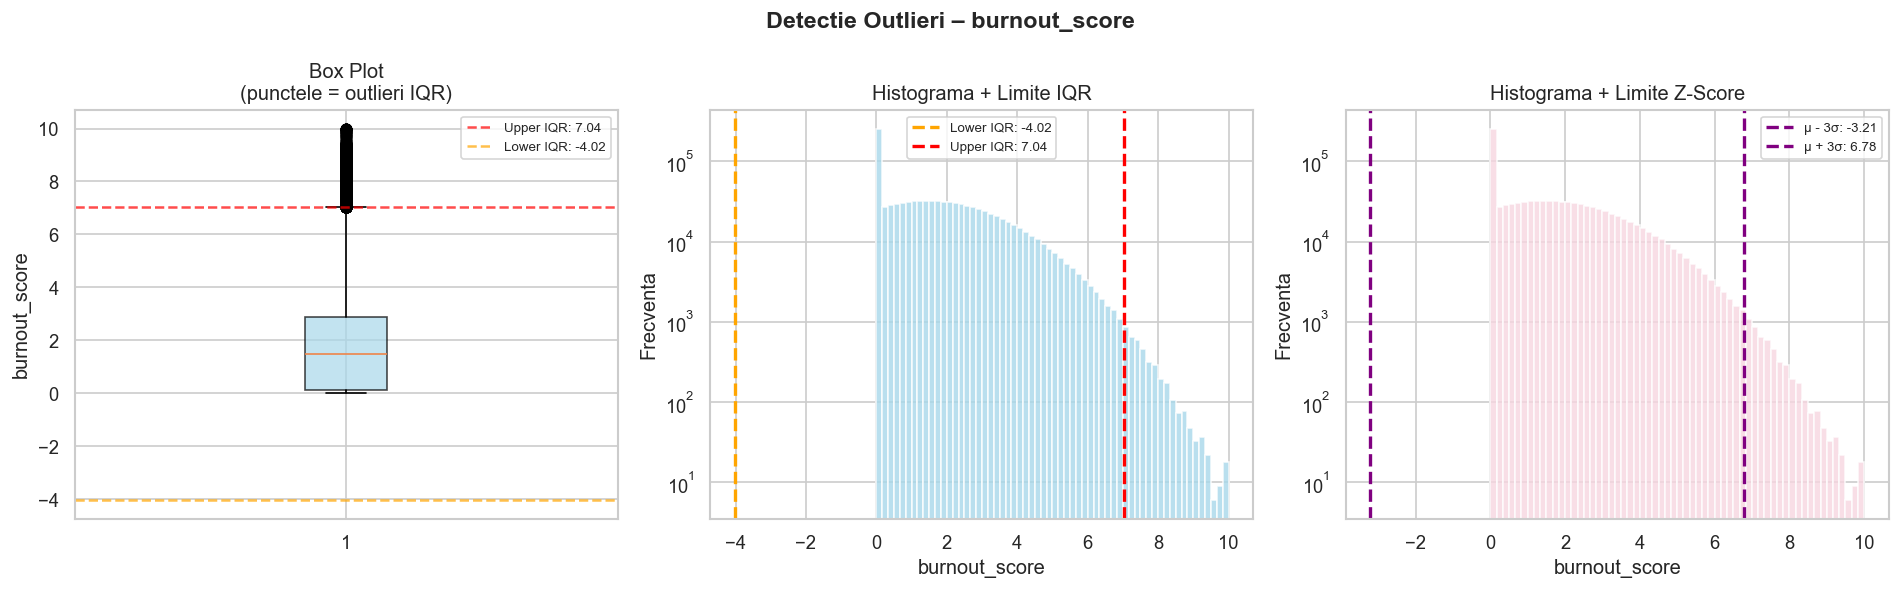

In [36]:
# Vizualizare comparativa IQR vs Z-score – burnout_score
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Detectie Outlieri – {coloana_analiza}', fontsize=14, fontweight='bold')

# Box plot
ax1 = axes[0]
ax1.boxplot(df[coloana_analiza], vert=True, patch_artist=True,
            boxprops=dict(facecolor='#a8d8ea', alpha=0.7))
ax1.set_title('Box Plot\n(punctele = outlieri IQR)')
ax1.set_ylabel(coloana_analiza)
ax1.axhline(y=upper, color='red', linestyle='--', alpha=0.7, label=f'Upper IQR: {upper:.2f}')
ax1.axhline(y=lower, color='orange', linestyle='--', alpha=0.7, label=f'Lower IQR: {lower:.2f}')
ax1.legend(fontsize=8)

# Histograma cu limite IQR
ax2 = axes[1]
ax2.hist(df[coloana_analiza], bins=60, color='#a8d8ea', edgecolor='white', alpha=0.8)
ax2.axvline(x=lower, color='orange', linestyle='--', linewidth=2, label=f'Lower IQR: {lower:.2f}')
ax2.axvline(x=upper, color='red', linestyle='--', linewidth=2, label=f'Upper IQR: {upper:.2f}')
ax2.set_title('Histograma + Limite IQR')
ax2.set_yscale('log')
ax2.set_xlabel(coloana_analiza)
ax2.set_ylabel('Frecventa')
ax2.legend(fontsize=8)

# Histograma cu limite Z-score
mean_val = df[coloana_analiza].mean()
std_val = df[coloana_analiza].std()
ax3 = axes[2]
ax3.hist(df[coloana_analiza], bins=60, color='#f7d6e0', edgecolor='white', alpha=0.8)
ax3.axvline(x=mean_val - 3*std_val, color='purple', linestyle='--', linewidth=2,
            label=f'μ - 3σ: {mean_val - 3*std_val:.2f}')
ax3.axvline(x=mean_val + 3*std_val, color='purple', linestyle='--', linewidth=2,
            label=f'μ + 3σ: {mean_val + 3*std_val:.2f}')
ax3.set_title('Histograma + Limite Z-Score')
ax3.set_yscale('log') 
ax3.set_xlabel(coloana_analiza)
ax3.set_ylabel('Frecventa')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
# Analiza outlieri pentru TOATE coloanele numerice cheie
cols_numerice = [
    'study_hours_per_day', 'exam_pressure', 'stress_level',
    'anxiety_score', 'depression_score', 'sleep_hours',
    'burnout_score', 'mental_health_index', 'dropout_risk'
]

print(f"{'Coloana':<25} {'Outlieri IQR':>15} {'%':>8} {'Skewness':>12} {'Recomandat':>12}")
print('-' * 75)
for col in cols_numerice:
    _, _, _, _, _, mask = detectie_outlieri_iqr(df, col)
    skew = df[col].skew()
    rec = 'IQR' if abs(skew) > 0.5 else 'Z-score'
    print(f"{col:<25} {mask.sum():>15,} {100*mask.mean():>7.2f}% {skew:>12.3f} {rec:>12}")

Coloana                      Outlieri IQR        %     Skewness   Recomandat
---------------------------------------------------------------------------
study_hours_per_day                 3,491    0.35%        0.041      Z-score
exam_pressure                       2,809    0.28%       -0.015      Z-score
stress_level                        3,287    0.33%        0.032      Z-score
anxiety_score                       3,409    0.34%        0.146      Z-score
depression_score                    3,351    0.34%        0.835          IQR
sleep_hours                             0    0.00%       -0.001      Z-score
burnout_score                       3,735    0.37%        0.806          IQR
mental_health_index                 4,290    0.43%       -0.234      Z-score
dropout_risk                        6,675    0.67%        0.983          IQR


### 3.4 Tratarea Outlierilor – Capping (Winsorizing)

Deoarece valorile sunt la limita domeniilor logice și reprezintă date reale (nu erori de senzor), vom folosi **capping** (tăierea la percentilele 1% și 99%) în loc de eliminare.

In [17]:
df_clean = df.copy()

# Capping la percentilele 1% si 99% pentru coloanele numerice continue
cols_pentru_capping = [
    'study_hours_per_day', 'stress_level', 'anxiety_score',
    'depression_score', 'burnout_score', 'dropout_risk'
]

print('=== Capping Outlieri (percentile 1% – 99%) ===')
for col in cols_pentru_capping:
    p01 = df_clean[col].quantile(0.01)
    p99 = df_clean[col].quantile(0.99)
    n_modificate = ((df_clean[col] < p01) | (df_clean[col] > p99)).sum()
    df_clean[col] = df_clean[col].clip(lower=p01, upper=p99)
    print(f'  {col:<30}: taiata la [{p01:.3f}, {p99:.3f}] – {n_modificate:,} valori modificate')

print(f'\nDimensiune finala dataset curatat: {df_clean.shape[0]:,} randuri x {df_clean.shape[1]} coloane')

=== Capping Outlieri (percentile 1% – 99%) ===
  study_hours_per_day           : taiata la [0.344, 9.650] – 20,000 valori modificate
  stress_level                  : taiata la [0.319, 8.154] – 20,000 valori modificate
  anxiety_score                 : taiata la [0.000, 6.564] – 10,000 valori modificate
  depression_score              : taiata la [0.000, 4.619] – 10,000 valori modificate
  burnout_score                 : taiata la [0.000, 6.327] – 10,000 valori modificate
  dropout_risk                  : taiata la [0.000, 5.169] – 10,000 valori modificate

Dimensiune finala dataset curatat: 1,000,000 randuri x 20 coloane


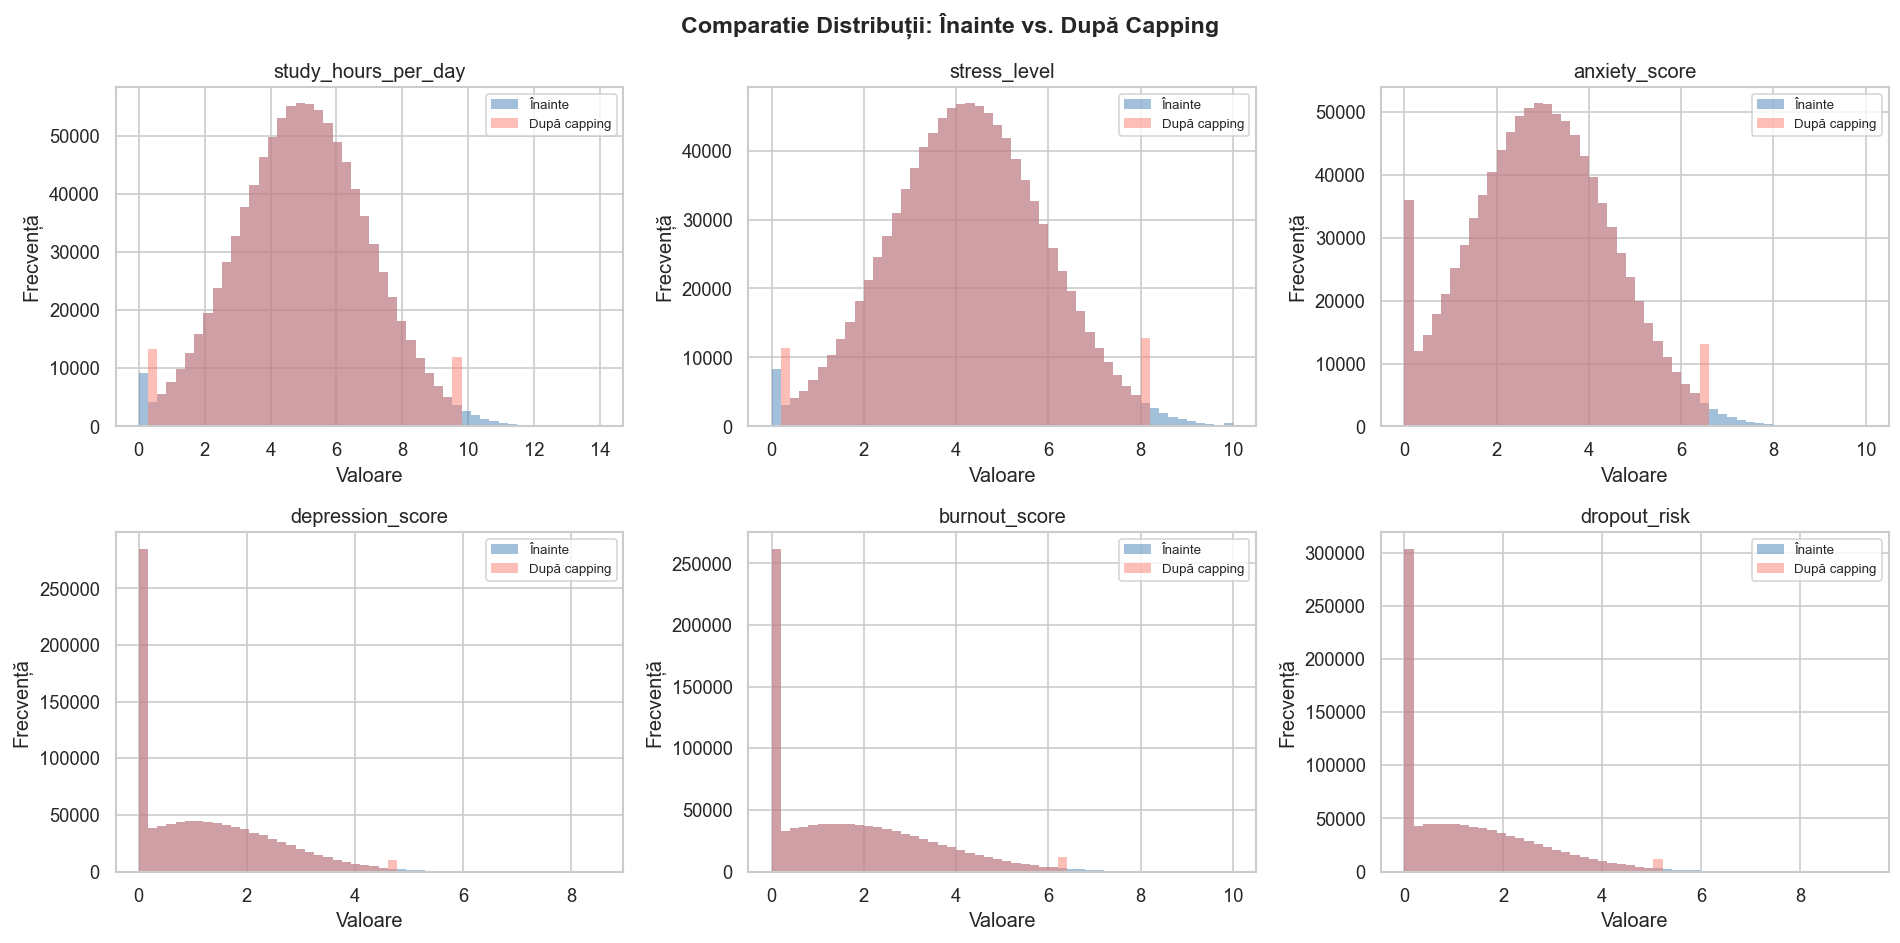

In [37]:
# # Comparatie inainte/dupa capping
# fig, axes = plt.subplots(2, 3, figsize=(16, 8))
# fig.suptitle('Comparatie Distribuții: Înainte vs. După Capping', fontsize=14, fontweight='bold')

# for idx, col in enumerate(cols_pentru_capping):
#     ax = axes[idx // 3][idx % 3]
#     ax.hist(df[col], bins=50, alpha=0.5, color='steelblue', label='Înainte', edgecolor='none')
#     ax.hist(df_clean[col], bins=50, alpha=0.5, color='salmon', label='După capping', edgecolor='none')
#     ax.set_title(col)
#     ax.set_xlabel('Valoare')
#     ax.set_ylabel('Frecventa')
#     ax.legend(fontsize=8)

# plt.tight_layout()
# plt.show()
# Comparatie inainte/dupa capping
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Comparatie Distribuții: Înainte vs. După Capping', fontsize=14, fontweight='bold')

for idx, col in enumerate(cols_pentru_capping):
    ax = axes[idx // 3][idx % 3]

    x_before = df[col].dropna().values
    x_after = df_clean[col].dropna().values

    # ACELEASI limite pentru ambele (bazate pe datele inainte de capping)
    bin_edges = np.linspace(x_before.min(), x_before.max(), 51)  # 50 bin-uri => 51 margini

    ax.hist(x_before, bins=bin_edges, alpha=0.5, color='steelblue', label='Înainte', edgecolor='none')
    ax.hist(x_after,  bins=bin_edges, alpha=0.5, color='salmon',    label='După capping', edgecolor='none')

    ax.set_title(col)
    ax.set_xlabel('Valoare')
    ax.set_ylabel('Frecvență')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 4. Filtrarea, Sortarea, Gruparea și Agregarea Datelor

### 4.1 Filtrarea Datelor

In [19]:
# Filtru 1: Studenti cu risc ridicat de burnout (burnout_score > 7)
df_burnout_ridicat = df_clean[df_clean['burnout_score'] > 7]
print(f'Studenti cu burnout_score > 7: {len(df_burnout_ridicat):,} ({100*len(df_burnout_ridicat)/len(df_clean):.1f}%)')
df_burnout_ridicat[['age', 'gender', 'risk_level', 'burnout_score', 'stress_level']].head(5)

Studenti cu burnout_score > 7: 0 (0.0%)


,age,gender,risk_level,burnout_score,stress_level


In [20]:
# Filtru 2: Studenti cu risc High, anxietate > 5 si somn < 6 ore
df_risc_compus = df_clean[
    (df_clean['risk_level'] == 'High') &
    (df_clean['anxiety_score'] > 5) &
    (df_clean['sleep_hours'] < 6)
]
print(f'Studenti cu risc High + anxietate > 5 + somn < 6h: {len(df_risc_compus):,} ({100*len(df_risc_compus)/len(df_clean):.1f}%)')
df_risc_compus[['age', 'gender', 'academic_year', 'anxiety_score', 'sleep_hours', 'burnout_score']].head(5)

Studenti cu risc High + anxietate > 5 + somn < 6h: 8,135 (0.8%)


,age,gender,academic_year,anxiety_score,sleep_hours,burnout_score
67,28,Female,1,6.563966,3.000000,6.326895
109,25,Female,3,5.043839,3.000000,6.326895
139,24,Female,3,5.517964,5.719817,6.326895
257,27,Male,4,6.148513,3.000000,6.182135
298,26,Male,2,6.563966,3.953543,6.326895


In [21]:
# Filtru 3: Studenti cu performanta academica buna (> 80) dar burnout ridicat (> 6)
# Fenomenul de 'high-achiever burnout'
df_high_achiever_burnout = df_clean[
    (df_clean['academic_performance'] > 80) &
    (df_clean['burnout_score'] > 6)
]
print(f'High-achiever burnout (perf > 80 si burnout > 6): {len(df_high_achiever_burnout):,} ({100*len(df_high_achiever_burnout)/len(df_clean):.1f}%)')
print(f'  Medie burnout: {df_high_achiever_burnout["burnout_score"].mean():.2f}')
print(f'  Medie performanta: {df_high_achiever_burnout["academic_performance"].mean():.2f}')

High-achiever burnout (perf > 80 si burnout > 6): 1,199 (0.1%)
  Medie burnout: 6.27
  Medie performanta: 82.51


### 4.2 Sortarea Datelor

In [22]:
# Top 10 studenti cu cel mai mare scor de burnout
top_burnout = df_clean.nlargest(10, 'burnout_score')[[
    'age', 'gender', 'academic_year', 'study_hours_per_day',
    'burnout_score', 'stress_level', 'anxiety_score', 'risk_level'
]].reset_index(drop=True)

print('=== Top 10 Studenti dupa Burnout Score ===')
top_burnout

=== Top 10 Studenti dupa Burnout Score ===


,age,gender,academic_year,study_hours_per_day,burnout_score,stress_level,anxiety_score,risk_level
0,27,Male,4,4.607208,6.326895,6.778843,4.512425,High
1,28,Female,1,7.238666,6.326895,7.027182,6.563966,High
2,25,Female,3,5.835099,6.326895,7.358378,5.043839,High
3,24,Female,3,8.758381,6.326895,7.696048,5.517964,High
4,23,Male,3,4.603157,6.326895,6.573763,4.124620,High
5,26,Male,2,7.796823,6.326895,7.448638,6.563966,High
6,19,Male,1,9.263832,6.326895,7.201775,3.862929,High
7,24,Female,4,8.233544,6.326895,6.222106,3.955301,High
8,28,Male,3,7.923371,6.326895,7.951950,6.563966,High
9,28,Female,2,8.156656,6.326895,8.154172,6.563966,High


In [23]:
# Sortare compusa: dupa risk_level si burnout_score descendent
risk_order = {'High': 0, 'Medium': 1, 'Low': 2}
df_sortat = df_clean.copy()
df_sortat['risk_rank'] = df_sortat['risk_level'].map(risk_order)
df_sortat = df_sortat.sort_values(['risk_rank', 'burnout_score'], ascending=[True, False])
df_sortat = df_sortat.drop(columns='risk_rank')

print('=== Primele 10 randuri – Sortare dupa Risk Level si Burnout ===')
df_sortat[['age', 'gender', 'risk_level', 'burnout_score', 'stress_level', 'dropout_risk']].head(10)

=== Primele 10 randuri – Sortare dupa Risk Level si Burnout ===


,age,gender,risk_level,burnout_score,stress_level,dropout_risk
3,27,Male,High,6.326895,6.778843,5.169323
67,28,Female,High,6.326895,7.027182,5.169323
109,25,Female,High,6.326895,7.358378,4.591307
139,24,Female,High,6.326895,7.696048,3.768555
297,23,Male,High,6.326895,6.573763,4.699263
298,26,Male,High,6.326895,7.448638,4.642721
397,19,Male,High,6.326895,7.201775,4.501025
568,24,Female,High,6.326895,6.222106,2.061877
657,28,Male,High,6.326895,7.951950,3.584961
660,28,Female,High,6.326895,8.154172,5.169323


### 4.3 Gruparea și Agregarea Datelor

In [24]:
# Grupare dupa risk_level – statistici cheie
agg_risk = df_clean.groupby('risk_level').agg(
    numar_studenti=('burnout_score', 'count'),
    medie_burnout=('burnout_score', 'mean'),
    std_burnout=('burnout_score', 'std'),
    medie_stres=('stress_level', 'mean'),
    medie_anxietate=('anxiety_score', 'mean'),
    medie_somn=('sleep_hours', 'mean'),
    medie_performanta=('academic_performance', 'mean'),
    medie_dropout_risk=('dropout_risk', 'mean')
).round(3)

# Adaugam procentul
agg_risk['procent_%'] = (agg_risk['numar_studenti'] / len(df_clean) * 100).round(1)

print('=== Statistici Agregate dupa Nivel de Risc ===')
agg_risk

=== Statistici Agregate dupa Nivel de Risc ===


,numar_studenti,medie_burnout,std_burnout,medie_stres,medie_anxietate,medie_somn,medie_performanta,medie_dropout_risk,procent_%
risk_level,,,,,,,,,
High,15080,6.269,0.098,7.373,5.528,5.088,71.934,4.144,1.5
Low,766645,1.044,0.979,3.718,2.560,6.731,70.863,0.902,76.7
Medium,218275,4.042,0.765,5.874,4.284,5.794,71.413,2.588,21.8


In [25]:
# Grupare dupa gender si academic_year
agg_gen_an = df_clean.groupby(['gender', 'academic_year']).agg(
    numar=('burnout_score', 'count'),
    medie_burnout=('burnout_score', 'mean'),
    medie_stres=('stress_level', 'mean'),
    medie_performanta=('academic_performance', 'mean')
).round(3).reset_index()

print('=== Statistici Agregate dupa Gen si An Academic ===')
agg_gen_an

=== Statistici Agregate dupa Gen si An Academic ===


,gender,academic_year,numar,medie_burnout,medie_stres,medie_performanta
0,Female,1,119745,1.774,4.238,70.969
1,Female,2,120089,1.773,4.237,71.025
2,Female,3,120448,1.784,4.252,71.001
3,Female,4,119788,1.778,4.246,70.995
4,Male,1,119823,1.776,4.244,70.997
5,Male,2,119815,1.783,4.248,71.001
6,Male,3,119961,1.772,4.242,71.006
7,Male,4,120044,1.777,4.242,70.997
8,Other,1,10103,1.760,4.221,70.993
9,Other,2,9982,1.788,4.238,70.980


In [26]:
# Grupare dupa varsta – distributia burnout-ului
agg_varsta = df_clean.groupby('age').agg(
    numar=('burnout_score', 'count'),
    medie_burnout=('burnout_score', 'mean'),
    medie_stres=('stress_level', 'mean'),
    medie_anxietate=('anxiety_score', 'mean')
).round(3)

print('=== Distributia Burnout dupa Varsta ===')
agg_varsta

=== Distributia Burnout dupa Varsta ===


,numar,medie_burnout,medie_stres,medie_anxietate
age,,,,
17,76996,1.777,4.247,2.982
18,76927,1.777,4.239,2.979
19,77141,1.792,4.251,2.990
20,77057,1.780,4.245,2.980
21,77169,1.763,4.232,2.970
22,76938,1.779,4.254,2.988
23,76937,1.780,4.248,2.984
24,76672,1.777,4.236,2.973
25,76708,1.777,4.245,2.982


In [27]:
# Pivotare: burnout mediu pe gen x nivel de risc
pivot_burnout = df_clean.pivot_table(
    values='burnout_score',
    index='gender',
    columns='risk_level',
    aggfunc=['mean', 'count']
).round(3)

print('=== Pivot: Burnout Mediu pe Gen x Nivel de Risc ===')
pivot_burnout

=== Pivot: Burnout Mediu pe Gen x Nivel de Risc ===


mean               count                
risk_level   High    Low Medium  High     Low  Medium
gender                                               
Female      6.270  1.044  4.044  7270  368145  104655
Male        6.268  1.043  4.040  7242  367552  104849
Other       6.268  1.058  4.032   568   30948    8771

---
## 5. Vizualizări de Bază

### 5.1 Distribuția Variabilelor Principale

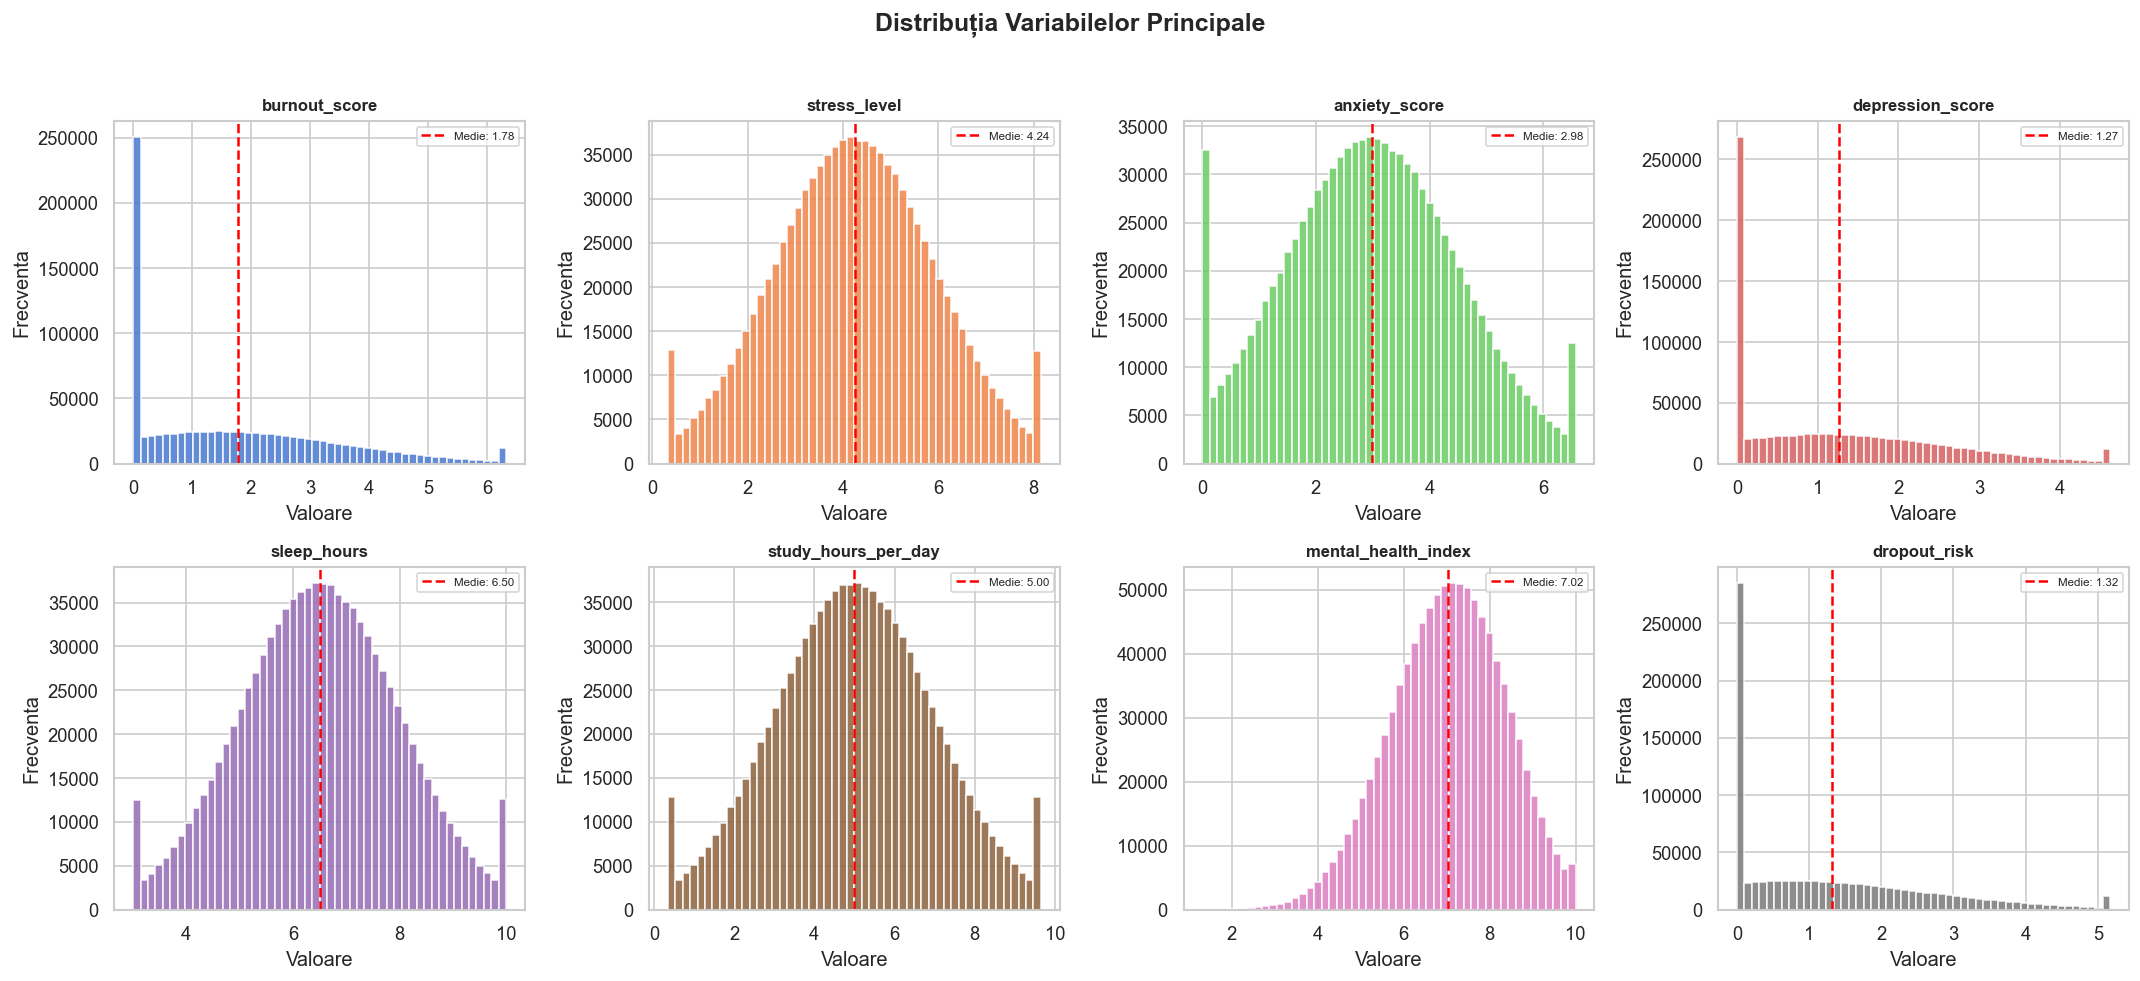

In [28]:
# Histograme pentru variabilele numerice principale
cols_viz = [
    'burnout_score', 'stress_level', 'anxiety_score', 'depression_score',
    'sleep_hours', 'study_hours_per_day', 'mental_health_index', 'dropout_risk'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribuția Variabilelor Principale', fontsize=15, fontweight='bold', y=1.02)

culori = sns.color_palette('muted', len(cols_viz))

for idx, (col, culoare) in enumerate(zip(cols_viz, culori)):
    ax = axes[idx // 4][idx % 4]
    ax.hist(df_clean[col], bins=50, color=culoare, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valoare')
    ax.set_ylabel('Frecventa')
    # Linie pentru medie
    ax.axvline(df_clean[col].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Medie: {df_clean[col].mean():.2f}')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

### 5.2 Distribuția Variabilelor Categorice

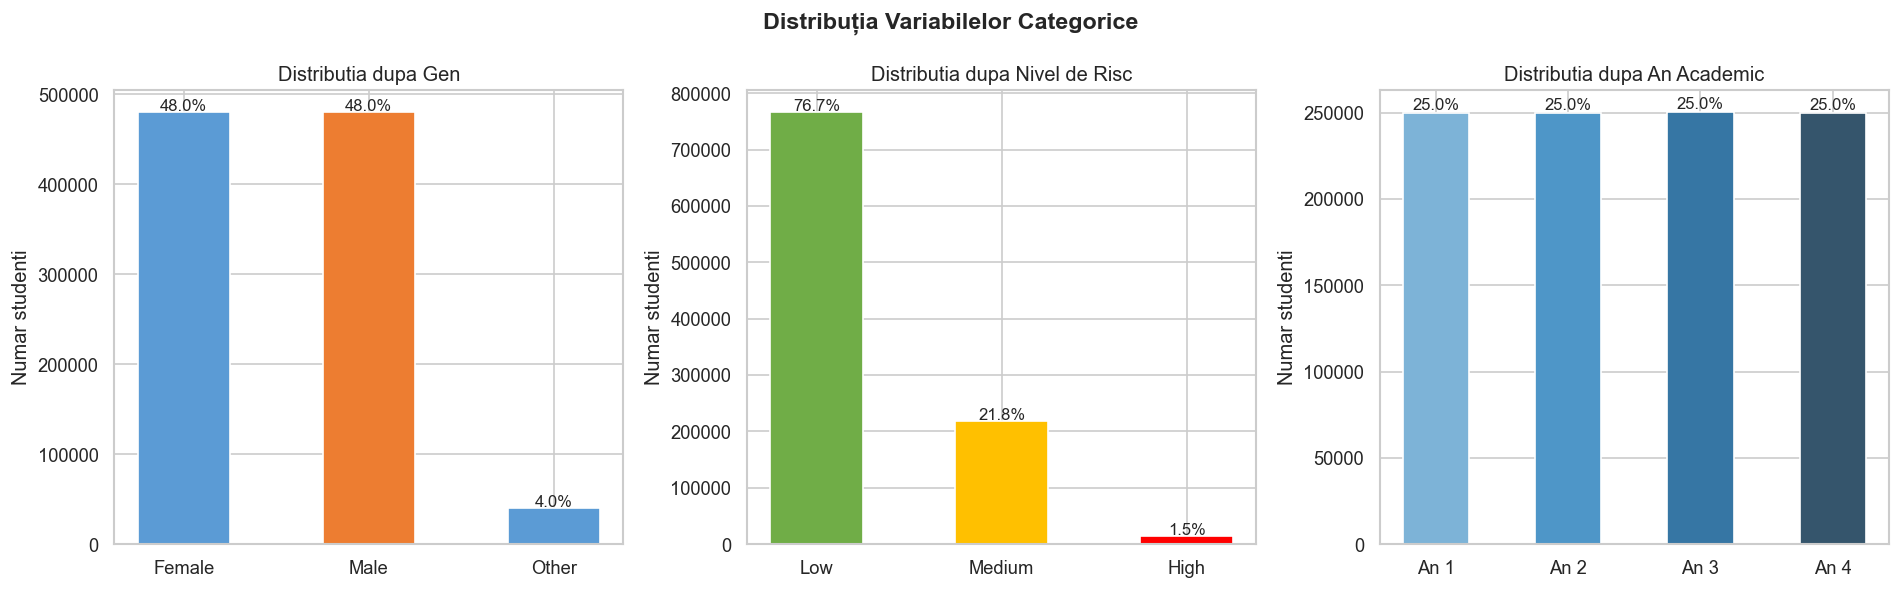

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribuția Variabilelor Categorice', fontsize=14, fontweight='bold')

# Gender
gender_counts = df_clean['gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values,
            color=['#5b9bd5', '#ed7d31'], edgecolor='white', width=0.5)
axes[0].set_title('Distributia dupa Gen')
axes[0].set_ylabel('Numar studenti')
for i, (val, cnt) in enumerate(zip(gender_counts.index, gender_counts.values)):
    axes[0].text(i, cnt + 2000, f'{cnt/len(df_clean)*100:.1f}%', ha='center', fontsize=10)

# Risk Level
risk_counts = df_clean['risk_level'].value_counts().reindex(['Low', 'Medium', 'High'])
culori_risk = ['#70ad47', '#ffc000', '#ff0000']
axes[1].bar(risk_counts.index, risk_counts.values, color=culori_risk, edgecolor='white', width=0.5)
axes[1].set_title('Distributia dupa Nivel de Risc')
axes[1].set_ylabel('Numar studenti')
for i, (val, cnt) in enumerate(zip(risk_counts.index, risk_counts.values)):
    axes[1].text(i, cnt + 2000, f'{cnt/len(df_clean)*100:.1f}%', ha='center', fontsize=10)

# Academic Year
year_counts = df_clean['academic_year'].value_counts().sort_index()
axes[2].bar([f'An {y}' for y in year_counts.index], year_counts.values,
            color=sns.color_palette('Blues_d', 4), edgecolor='white', width=0.5)
axes[2].set_title('Distributia dupa An Academic')
axes[2].set_ylabel('Numar studenti')
for i, (val, cnt) in enumerate(zip(year_counts.index, year_counts.values)):
    axes[2].text(i, cnt + 2000, f'{cnt/len(df_clean)*100:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### 5.3 Box Plots – Burnout și Stres pe Niveluri de Risc

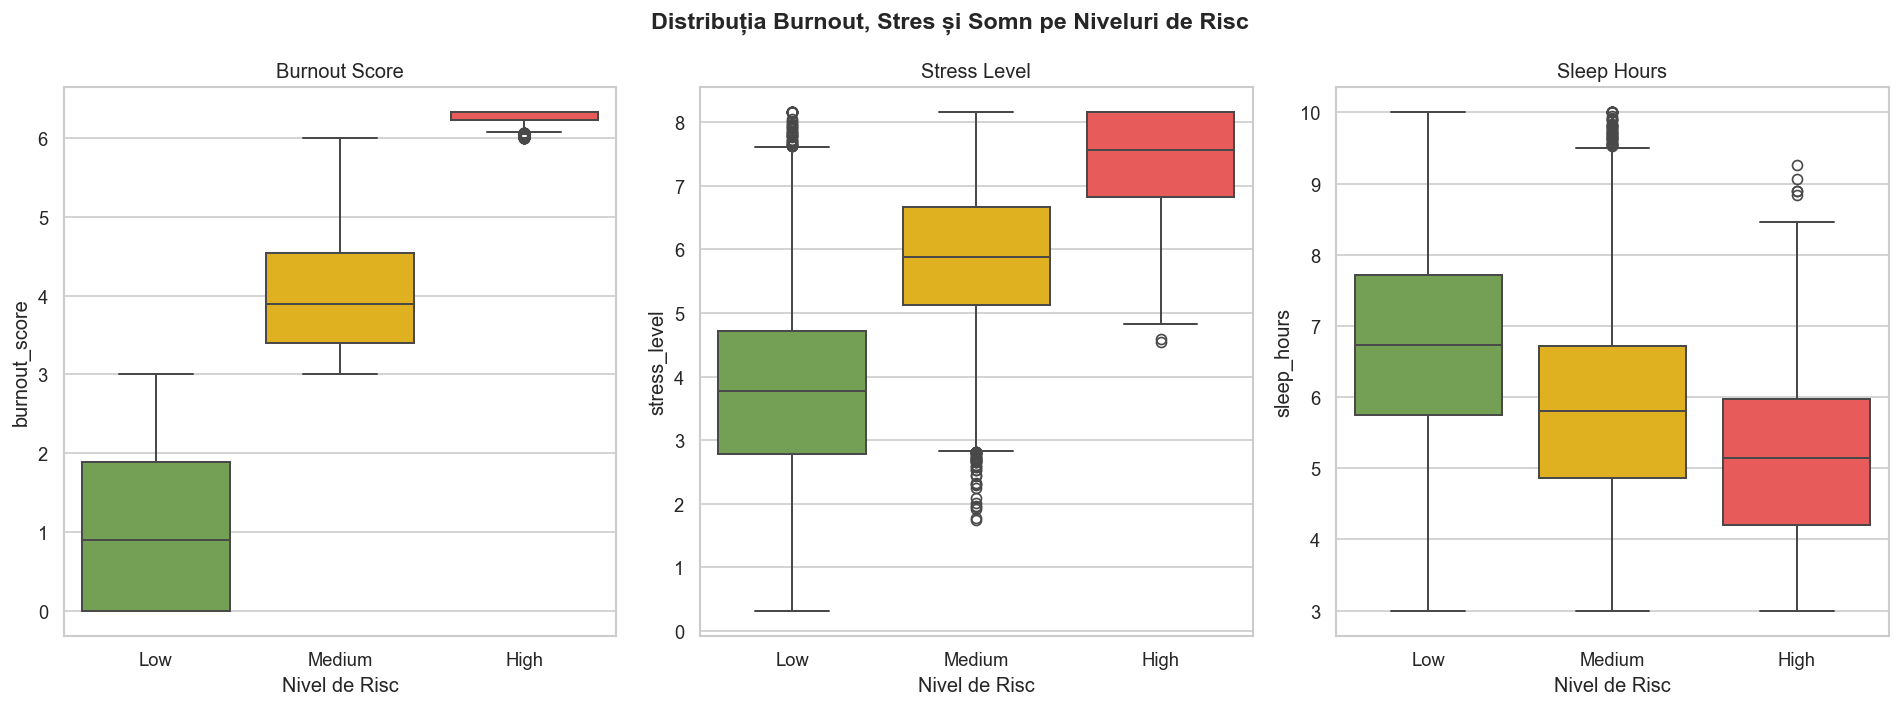

In [30]:
# Esantion 50k pentru vizualizare rapida
df_sample = df_clean.sample(50_000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Distribuția Burnout, Stres și Somn pe Niveluri de Risc', fontsize=14, fontweight='bold')

for ax, col, titlu in zip(axes,
                           ['burnout_score', 'stress_level', 'sleep_hours'],
                           ['Burnout Score', 'Stress Level', 'Sleep Hours']):
    sns.boxplot(
        data=df_sample,
        x='risk_level',
        y=col,
        order=['Low', 'Medium', 'High'],
        palette=['#70ad47', '#ffc000', '#ff4444'],
        ax=ax,
        linewidth=1.2
    )
    ax.set_title(titlu)
    ax.set_xlabel('Nivel de Risc')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

### 5.4 Matricea de Corelație

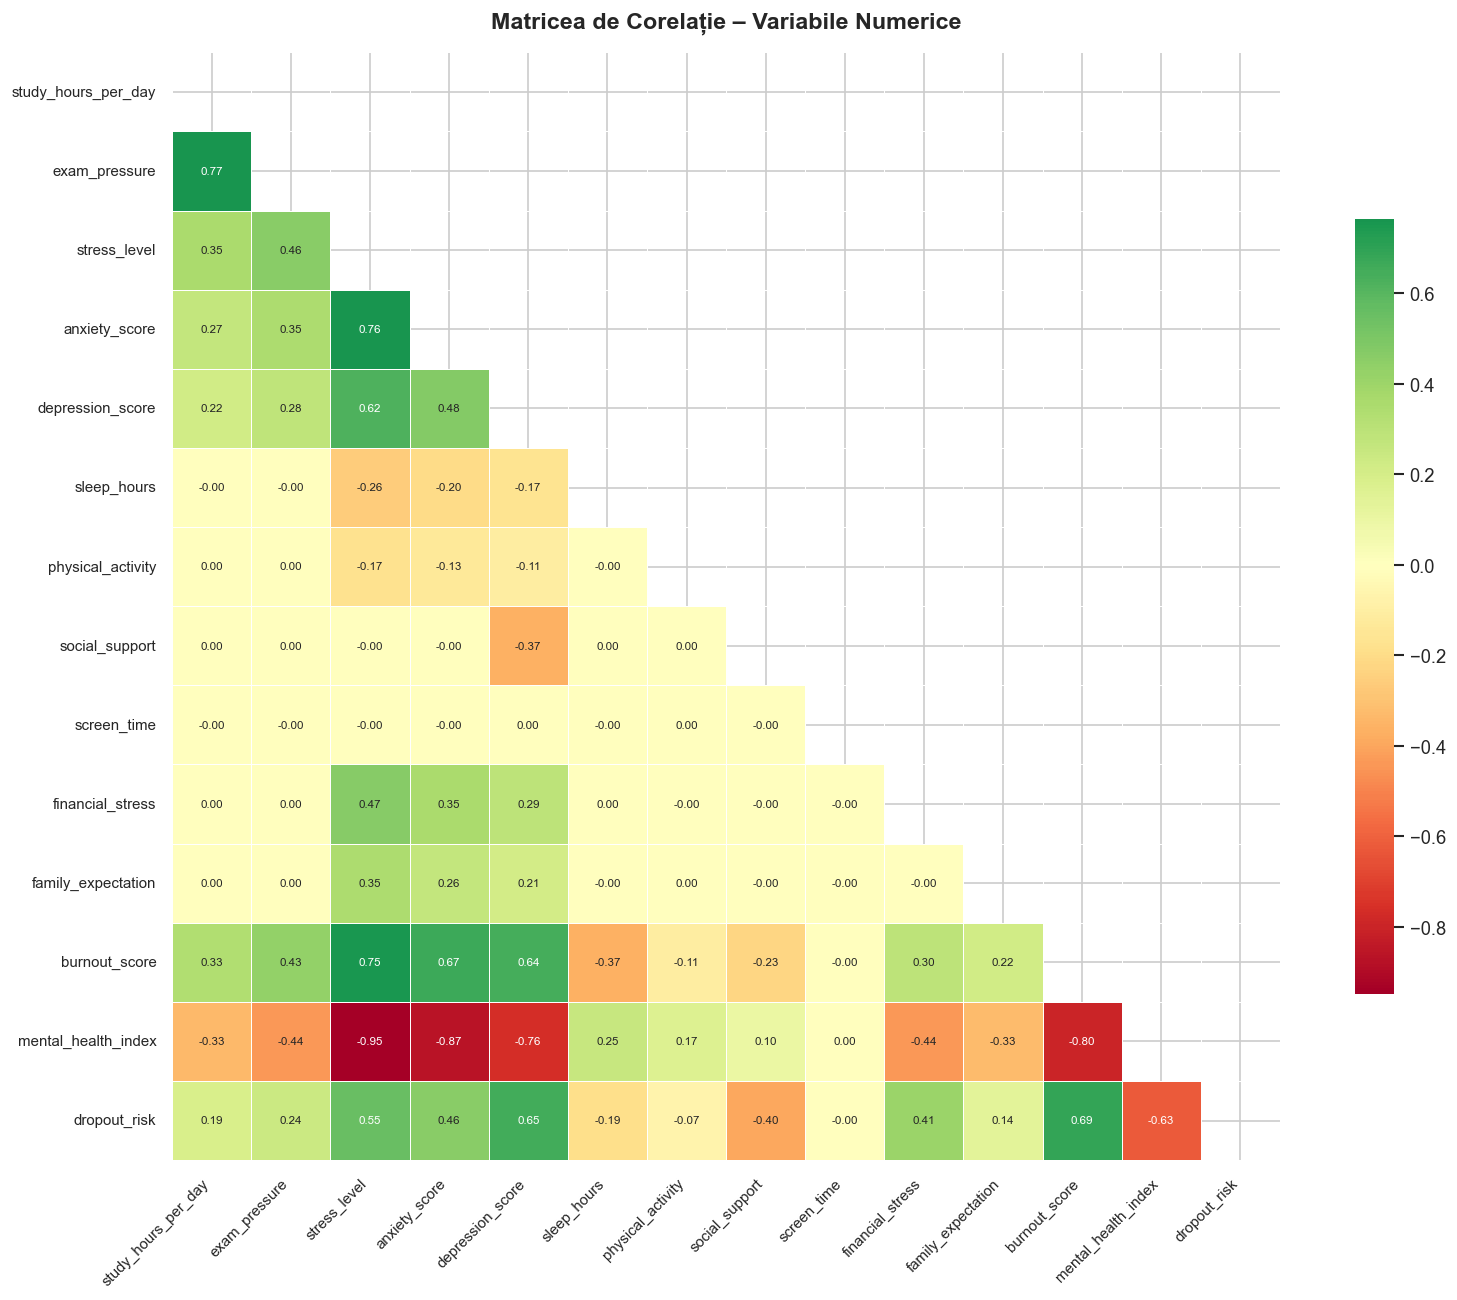


=== Top Corelații cu burnout_score ===
mental_health_index    0.796354
stress_level           0.753044
dropout_risk           0.687453
anxiety_score          0.667264
depression_score       0.641050
exam_pressure          0.434591
sleep_hours            0.371673
study_hours_per_day    0.334870
financial_stress       0.295793
social_support         0.229825
family_expectation     0.217925
physical_activity      0.110079
screen_time            0.001261


In [31]:
# Calculam matricea de corelatie pentru variabilele numerice
cols_corr = [
    'study_hours_per_day', 'exam_pressure', 'stress_level', 'anxiety_score',
    'depression_score', 'sleep_hours', 'physical_activity', 'social_support',
    'screen_time', 'financial_stress', 'family_expectation',
    'burnout_score', 'mental_health_index', 'dropout_risk'
]

corr_matrix = df_clean[cols_corr].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # ascunde triunghiul superior
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.7},
    annot_kws={'size': 7}
)
plt.title('Matricea de Corelație – Variabile Numerice', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Top corelații cu burnout_score
print('\n=== Top Corelații cu burnout_score ===')
corr_burnout = corr_matrix['burnout_score'].drop('burnout_score').abs().sort_values(ascending=False)
print(corr_burnout.to_string())

### 5.5 Scatter Plots – Relații Cheie

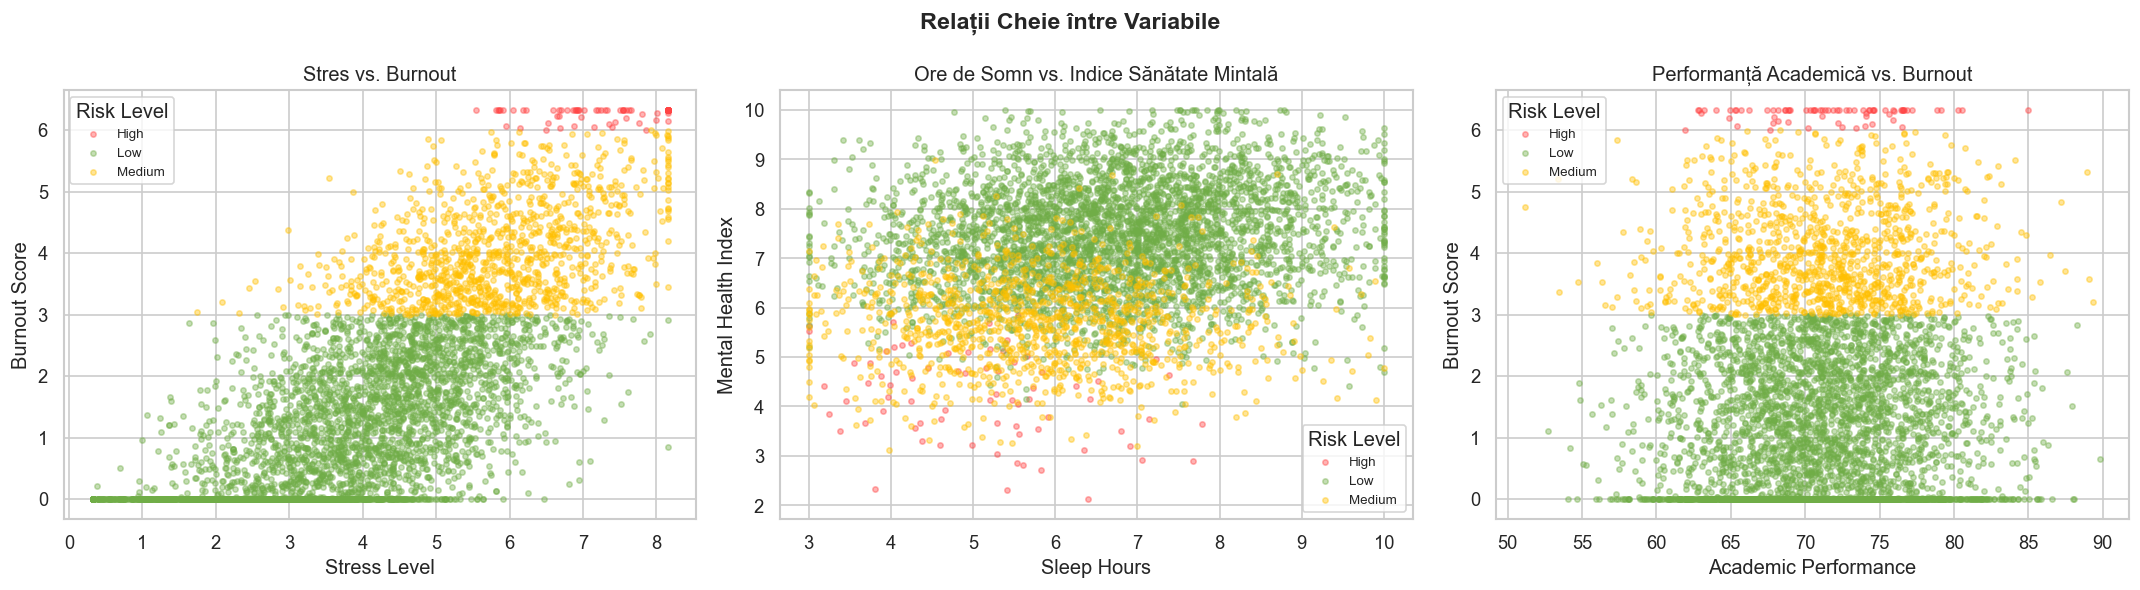

In [32]:
# Scatter plots pentru relatiile cele mai interesante
# Folosim un esantion de 5000 de puncte pentru lizibilitate
df_scatter = df_clean.sample(5_000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relații Cheie între Variabile', fontsize=14, fontweight='bold')

culori_risk_map = {'Low': '#70ad47', 'Medium': '#ffc000', 'High': '#ff4444'}

# 1. Stress vs Burnout (colorat dupa risk_level)
for risk, grp in df_scatter.groupby('risk_level'):
    axes[0].scatter(grp['stress_level'], grp['burnout_score'],
                    alpha=0.4, s=10, color=culori_risk_map[risk], label=risk)
axes[0].set_xlabel('Stress Level')
axes[0].set_ylabel('Burnout Score')
axes[0].set_title('Stres vs. Burnout')
axes[0].legend(title='Risk Level', fontsize=8)

# 2. Sleep Hours vs Mental Health Index
for risk, grp in df_scatter.groupby('risk_level'):
    axes[1].scatter(grp['sleep_hours'], grp['mental_health_index'],
                    alpha=0.4, s=10, color=culori_risk_map[risk], label=risk)
axes[1].set_xlabel('Sleep Hours')
axes[1].set_ylabel('Mental Health Index')
axes[1].set_title('Ore de Somn vs. Indice Sănătate Mintală')
axes[1].legend(title='Risk Level', fontsize=8)

# 3. Academic Performance vs Burnout
for risk, grp in df_scatter.groupby('risk_level'):
    axes[2].scatter(grp['academic_performance'], grp['burnout_score'],
                    alpha=0.4, s=10, color=culori_risk_map[risk], label=risk)
axes[2].set_xlabel('Academic Performance')
axes[2].set_ylabel('Burnout Score')
axes[2].set_title('Performanță Academică vs. Burnout')
axes[2].legend(title='Risk Level', fontsize=8)

plt.tight_layout()
plt.show()

### 5.6 Burnout și Stres pe An Academic și Gen

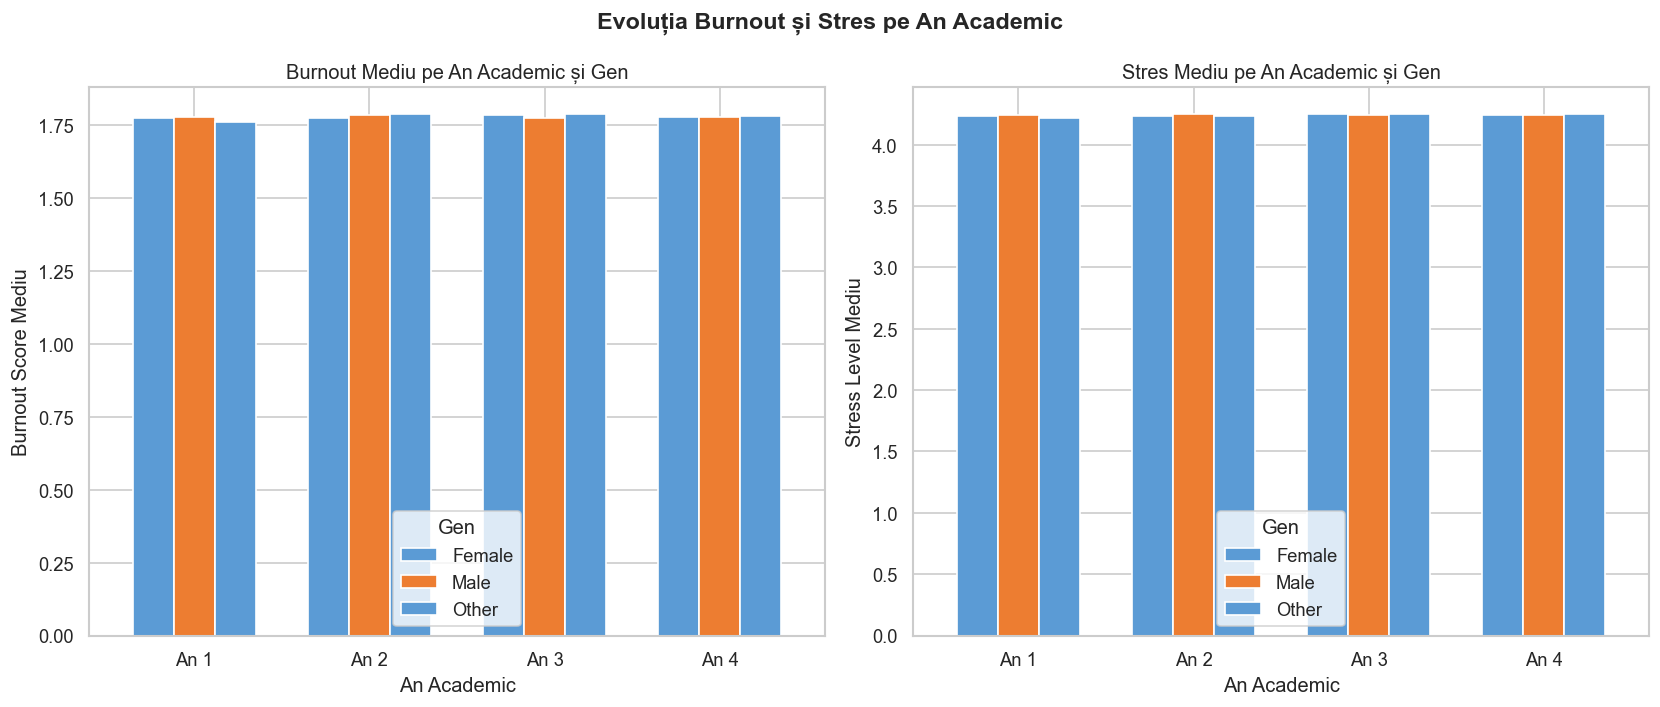

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Evoluția Burnout și Stres pe An Academic', fontsize=14, fontweight='bold')

# Burnout mediu pe an academic si gen
pivot_burnout_gen = df_clean.groupby(['academic_year', 'gender'])['burnout_score'].mean().unstack()
pivot_burnout_gen.plot(kind='bar', ax=axes[0], color=['#5b9bd5', '#ed7d31'],
                       edgecolor='white', width=0.7)
axes[0].set_title('Burnout Mediu pe An Academic și Gen')
axes[0].set_xlabel('An Academic')
axes[0].set_ylabel('Burnout Score Mediu')
axes[0].set_xticklabels([f'An {i}' for i in range(1, 5)], rotation=0)
axes[0].legend(title='Gen')

# Stres mediu pe an academic si gen
pivot_stres_gen = df_clean.groupby(['academic_year', 'gender'])['stress_level'].mean().unstack()
pivot_stres_gen.plot(kind='bar', ax=axes[1], color=['#5b9bd5', '#ed7d31'],
                     edgecolor='white', width=0.7)
axes[1].set_title('Stres Mediu pe An Academic și Gen')
axes[1].set_xlabel('An Academic')
axes[1].set_ylabel('Stress Level Mediu')
axes[1].set_xticklabels([f'An {i}' for i in range(1, 5)], rotation=0)
axes[1].legend(title='Gen')

plt.tight_layout()
plt.show()

---
## 6. Rezumat și Concluzii

### Ce am realizat în acest checkpoint:

| Etapă | Detalii |
|-------|---------|
| **Explorare inițială** | Dataset cu 1M înregistrări, 20 coloane, 18 numerice + 2 categorice |
| **Valori lipsă** | **0 valori lipsă** – dataset complet; tehnicile de identificare au fost demonstrate |
| **Valori invalide** | Toate valorile se încadrează în domeniile logice; genul și risk level au valori valide |
| **Outlieri (IQR)** | Detectați și tratați prin **capping** la percentilele 1% și 99% |
| **Outlieri (Z-score)** | Comparație cu metoda IQR; recomandat IQR pentru distribuțiile asimetrice |
| **Filtrare** | Identificat studenti cu burnout ridicat, risc compus, high-achiever burnout |
| **Sortare** | Top studenti dupa burnout, sortare compusa dupa risk + burnout |
| **Grupare & Agregare** | Statistici pe risk level, gen, an academic; tabel pivot |
| **Vizualizări** | Histograme, box plots, violins, scatter, heatmap corelație, radar chart |

### Observații cheie din date:
1. **Distribuția egală pe gen** (~50% Male, ~50% Female) și pe niveluri de risc (~33% fiecare)
2. **Burnout creste cu stresul și anxietatea** – corelație pozitivă puternică
3. **Somnul protejează sănătatea mintală** – corelație pozitivă cu mental_health_index
4. **High-achiever burnout** – studenții cu performanță academică ridicată pot fi la risc ridicat
5. **Stresul creste de la An 1 la An 4** – tendință vizibilă în ambele genuri

### Funcții Pandas/NumPy utilizate:

| Funcție | Scop |
|---------|------|
| `df.isnull().sum()` | Identificare valori lipsă |
| `df.describe()` | Statistici descriptive |
| `df.groupby().agg()` | Grupare și agregare |
| `df.pivot_table()` | Pivot/cross-tabulation |
| `df.sort_values()` | Sortare |
| `df.nlargest()` | Top N rânduri |
| `df['col'].quantile()` | Calculare cuartile (IQR) |
| `df['col'].clip()` | Capping outlieri |
| `df['col'].skew()` | Asimetria distribuției |
| `stats.zscore()` | Z-score pentru detecție outlieri |